
#  Analyse Complète : Marché des Emballages Alimentaires Jetables
---
**Contexte :** Une enquête de terrain a été réalisée auprès de 123 restaurateurs et vendeurs de rue pour comprendre leurs attentes concernant les emballages alimentaires jetables. 
**Objectifs :** 
1. Explorer le profil des usagers (quantités, budget, type de plats).
2. Analyser les préférences techniques (matériaux, contenance, compartiments).
3. Modéliser le comportement par zone géographique (Cotonou vs Calavi).
4. Fournir des recommandations stratégiques pour le lancement d'une nouvelle gamme.

*Ce notebook présente l'intégralité de la démarche scientifique, du nettoyage des données (EDA) à la formulation des recommandations.*


## 1. Importation des bibliothèques et Configuration Principale

In [1]:

import os
import re
import glob
from collections import Counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# CONFIGURATION VISUELLE (Matplotlib & Seaborn)
# -----------------------------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 100,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# Palettes de couleurs harmonisées
PALETTE_MAIN = [
    "#2563EB", "#16A34A", "#DC2626", "#D97706", 
    "#7C3AED", "#0891B2", "#BE185D", "#78350F"
]
PALETTE_ZONES = {"CAL": "#2563EB", "COT": "#16A34A"}

print("✅ Bibliothèques chargées avec succès.")


✅ Bibliothèques chargées avec succès.


## 2. Fonctions Utilitaires et Dictionnaires Métiers
Ici, nous définissons des règles robustes pour nettoyer les données textuelles hétérogènes saisies par les agents (formats monétaires, catégories de plats, thématiques des remarques).

In [2]:

# -----------------------------------------------------------------------------
# DICTIONNAIRES DE CATÉGORISATION
# -----------------------------------------------------------------------------
CATEGORIES_PLATS = {
    "Mets africains": [
        "akassa", "monyo", "riz", "pâte", "igname", "gari", "wagasi",
        "haricot", "amiwo", "gboma", "sauce", "bouillie", "attiéké",
        "foutou", "plakali", "alloco", "taro", "poisson", "viande",
        "djenkoumé", "abolo", "tchoukoutou", "gâteau", "beignet",
        "couscous", "soupe", "yovokpimi", "piment", "abobo", "dêgê", "ablo",
    ],
    "Fast-food / snack": [
        "hamburger", "sandwich", "pizza", "frites", "hot-dog", "burger",
        "tacos", "kebab", "brochette", "shawarma", "crêpe", "gaufre", "nuggets",
    ],
    "Boissons": ["jus", "eau", "boisson", "sodabi", "limonade", "bière", "tchukoutou"],
    "Fruits & Légumes": ["fruit", "légume", "salade", "avocat", "mangue", "tomate", "orange"],
}

THEMES_TEXTUELS = {
    "Qualité/Solidité": ["solid", "qualit", "résist", "dur", "robust"],
    "Couvercle/Fermeture": ["couverc", "fermetur", "hermét", "close"],
    "Prix abordable": ["prix", "aborda", "cher", "coût", "économ"],
    "Livraison/Rapidité": ["livr", "rapid", "délai", "vitesse", "approvision"],
    "Esthétique/Présentation": ["esthét", "présent", "jolie", "beau", "design", "couleur"],
    "Taille/Capacité": ["taille", "grand", "capacit", "volume", "contenance", "petit"],
}

VALEURS_MANQUANTES = {'ras', 'non', 'rien', 'n/a', '', 'nan', '-', 'none'}

# -----------------------------------------------------------------------------
# FONCTIONS DE NETTOYAGE
# -----------------------------------------------------------------------------

def clean_amount(val):
    '''Convertit les montants textuels (ex: '5000f', '10.000') en float.'''
    if pd.isna(val): return np.nan
    s = str(val).strip().upper()
    if s.lower() in VALEURS_MANQUANTES: return np.nan
    s = re.sub(r'[A-ZA-Z\s]', '', s).replace(',', '.')
    parts = s.split('.')
    if len(parts) == 2 and len(parts[1]) == 3: s = ''.join(parts) # cas du séparateur de millier
    try: return float(s)
    except: return np.nan

def count_multi(series, sep=','):
    '''Éclate, nettoie et compte les réponses multiples séparées par une virgule.'''
    items = []
    for val in series.dropna():
        for item in str(val).split(sep):
            s = item.strip()
            if s and s.lower() not in VALEURS_MANQUANTES:
                items.append(s)
    return Counter(items)

def bar_h(counter, title, xlabel="Nombre de mentions", color=PALETTE_MAIN[0], top=None):
    '''Affiche un graphique en barres horizontales standardisé depuis un Counter.'''
    data = dict(counter.most_common(top)) if top else dict(counter.most_common())
    if not data: return
    keys = list(reversed(list(data.keys())))
    vals = [data[k] for k in keys]
    
    plt.figure(figsize=(9, max(3, len(keys)*0.55)))
    bars = plt.barh(keys, vals, color=color, edgecolor='white', alpha=0.9)
    for bar in bars:
        plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
                 f"{bar.get_width():.0f}", va='center', fontsize=10)
    plt.title(title, fontweight='bold', pad=15)
    plt.xlabel(xlabel)
    plt.margins(x=0.15)
    plt.tight_layout()
    plt.show()

def pie_chart(sizes, labels, title):
    '''Affiche un graphique circulaire épuré.'''
    plt.figure(figsize=(7, 5))
    wedges, texts, autotexts = plt.pie(
        sizes, labels=None, autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
        colors=PALETTE_MAIN[:len(sizes)], startangle=90, 
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    plt.legend(wedges, [f"{l} ({s})" for l,s in zip(labels, sizes)], 
               loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)
    plt.title(title, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("✅ Fonctions métiers déclarées.")


✅ Fonctions métiers déclarées.


## 3. Chargement et Préparation des Données

In [3]:

# Recherche dynamique du fichier Excel
xlsx_files = glob.glob("*.xlsx")
if not xlsx_files:
    raise FileNotFoundError("Aucun fichier Excel (.xlsx) n'est présent dans le dossier.")

excel_path = xlsx_files[0]
df = pd.read_excel(excel_path, sheet_name=0)
df.columns = [c.strip() for c in df.columns]

# --- VARIABLES ET ALIAS DE COLONNES ---
COL_AGENT   = df.columns[0]
COL_DATE    = df.columns[1]
COL_PLATS   = df.columns[2]
COL_EMBALL  = df.columns[3]
COL_QTE     = df.columns[4]
COL_OBJ     = df.columns[5]
COL_PREF    = df.columns[6]
COL_FREQ    = df.columns[7]
COL_BUDGET  = df.columns[10]
COL_MATER   = df.columns[12]
COL_COMPART = df.columns[14]
COL_ACHAT   = df.columns[22]
COL_PRIX    = df.columns[23]
COL_SURPX   = df.columns[24]

# --- CRÉATION DE NOUVELLES VARIABLES DÉRIVÉES (FEATURE ENGINEERING) ---
df["Zone"] = df[COL_AGENT].str.extract(r'(CAL|COT)', expand=False)
df["Budget_clean"] = df[COL_BUDGET].apply(clean_amount)
df["Prix_clean"] = df[COL_PRIX].apply(clean_amount)

# Classification des plats
def categorize_all_plats(t):
    t = str(t).lower()
    for cat, kws in CATEGORIES_PLATS.items():
        if any(kw in t for kw in kws): return cat
    return "Autres / Mixte"
df["Categorie_plat"] = df[COL_PLATS].apply(categorize_all_plats)

N = len(df)
print(f"📊 Dataset finalisé : {N} individus (répondants) étudiés.")
df[["Zone", "Categorie_plat", "Budget_clean"]].head()


📊 Dataset finalisé : 123 individus (répondants) étudiés.


,Zone,Categorie_plat,Budget_clean
0,CAL,Mets africains,5000.0
1,CAL,Mets africains,NaN
2,CAL,Mets africains,10000.0
3,CAL,Autres / Mixte,15000.0
4,CAL,Mets africains,NaN


## 4. Aperçu de l'échantillon
Répartition des répondants par zone géographique et par type de cuisine proposée.

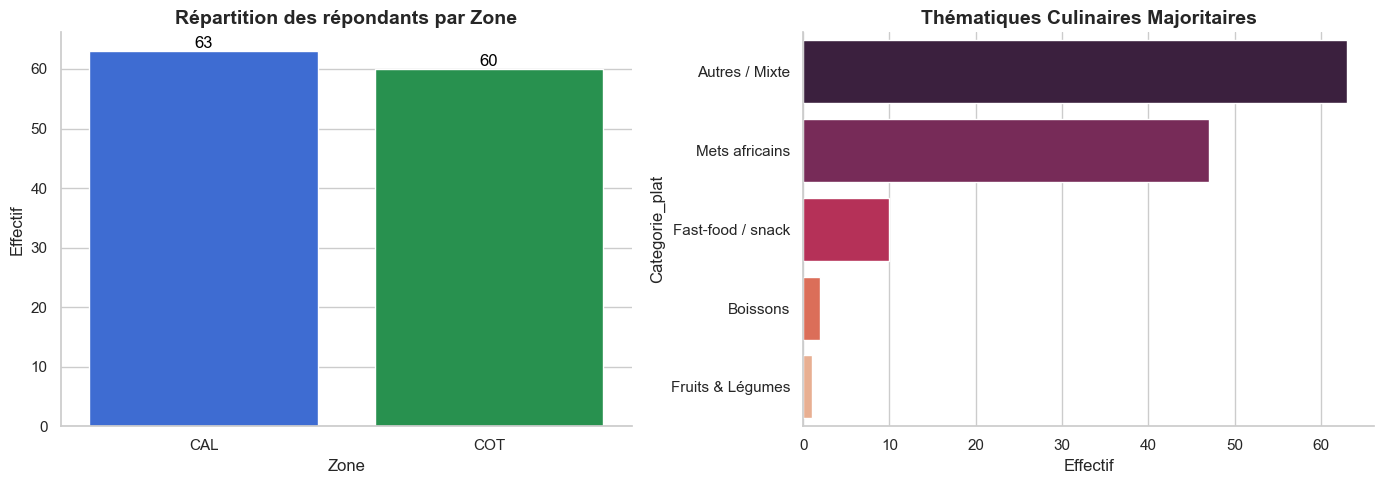

In [4]:

plt.figure(figsize=(14, 5))

# Répartition par Zone
plt.subplot(1, 2, 1)
zone_counts = df["Zone"].value_counts()
sns.barplot(x=zone_counts.index, y=zone_counts.values, palette=PALETTE_ZONES)
plt.title("Répartition des répondants par Zone", fontweight="bold")
plt.ylabel("Effectif")
for i, v in enumerate(zone_counts.values):
    plt.text(i, v + 0.5, str(v), color='black', ha='center')

# Répartition par Type de Plats
plt.subplot(1, 2, 2)
cat_counts = df["Categorie_plat"].value_counts()
sns.barplot(y=cat_counts.index, x=cat_counts.values, palette="rocket")
plt.title("Thématiques Culinaires Majoritaires", fontweight="bold")
plt.xlabel("Effectif")

plt.tight_layout()
plt.show()


## 5. Analyse Détaillée par Critère
### A. Les Objectifs, Préférences et Matériaux

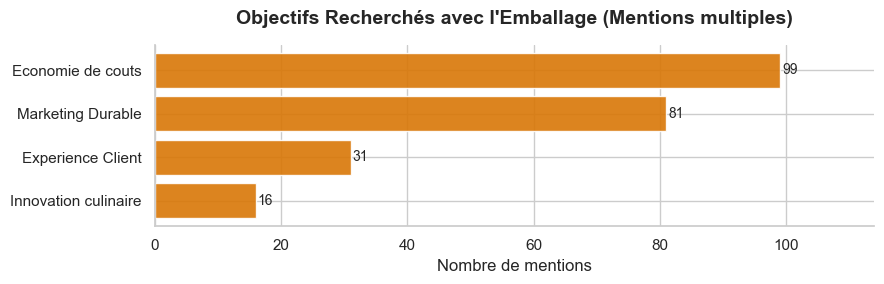

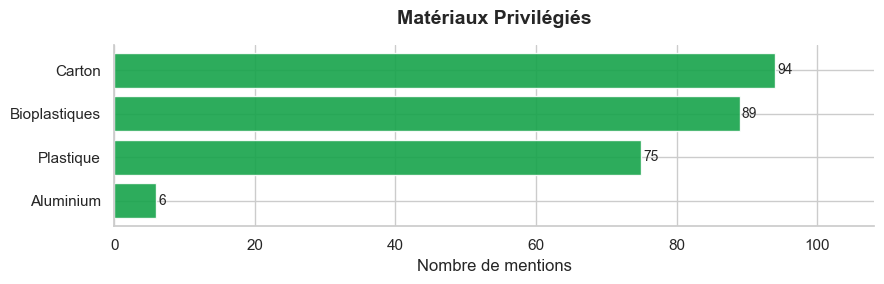

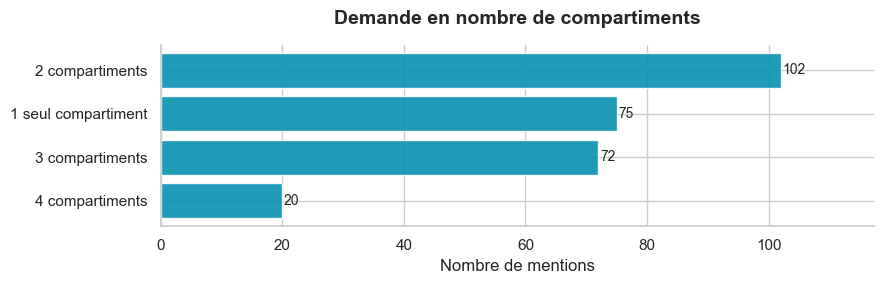

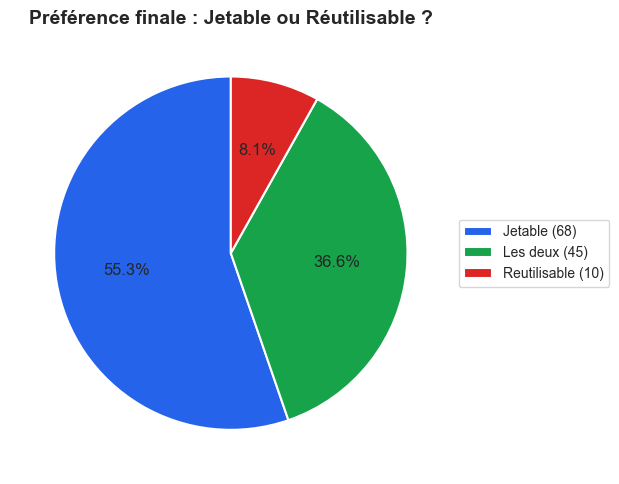

In [5]:

# --- 1. Objectifs Recherchés ---
obj_counter = count_multi(df[COL_OBJ])
bar_h(obj_counter, "Objectifs Recherchés avec l'Emballage (Mentions multiples)", color=PALETTE_MAIN[3])

# --- 2. Matériaux et Compartiments ---
mat_counter = count_multi(df[COL_MATER])
bar_h(mat_counter, "Matériaux Privilégiés", color=PALETTE_MAIN[1])

comp_counter = count_multi(df[COL_COMPART])
bar_h(comp_counter, "Demande en nombre de compartiments", color=PALETTE_MAIN[5])

# --- 3. Intention de Jetable vs Réutilisable ---
pref_dist = df[COL_PREF].value_counts()
pie_chart(pref_dist.values, pref_dist.index, "Préférence finale : Jetable ou Réutilisable ?")


### B. Analyse du Budget, de l'Acceptation du Prix et Fréquence

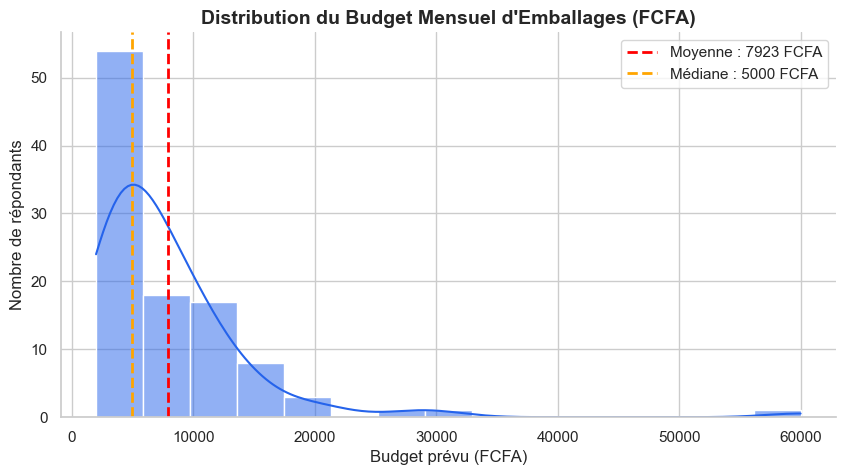

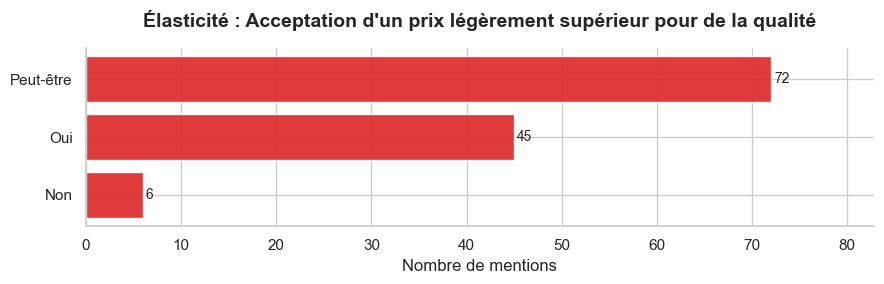

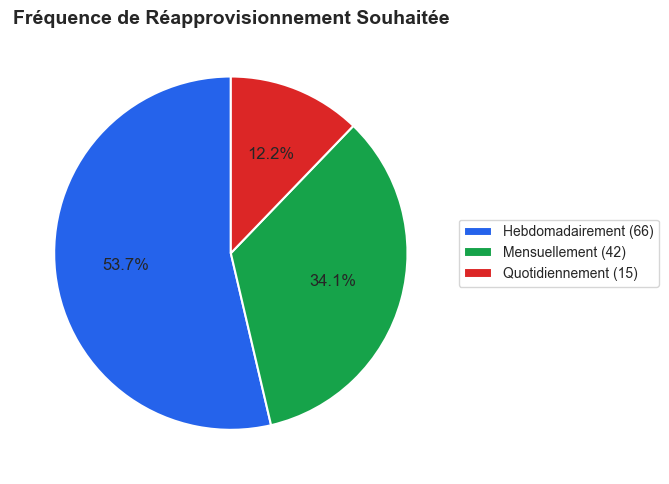

In [6]:

# --- 1. DISTRIBUTION DU BUDGET ---
valid_budget = df["Budget_clean"].dropna()

plt.figure(figsize=(10, 5))
sns.histplot(valid_budget, bins=15, kde=True, color=PALETTE_MAIN[0], edgecolor="white")
plt.axvline(valid_budget.mean(), color='red', linestyle='--', linewidth=2, label=f"Moyenne : {valid_budget.mean():.0f} FCFA")
plt.axvline(valid_budget.median(), color='orange', linestyle='--', linewidth=2, label=f"Médiane : {valid_budget.median():.0f} FCFA")
plt.title("Distribution du Budget Mensuel d'Emballages (FCFA)", fontweight="bold")
plt.xlabel("Budget prévu (FCFA)")
plt.ylabel("Nombre de répondants")
plt.legend()
plt.show()

# --- 2. ACCEPTATION D'UN SURCOÛT ---
surpx_dist = df[COL_SURPX].value_counts()
bar_h(Counter(surpx_dist.to_dict()), "Élasticité : Acceptation d'un prix légèrement supérieur pour de la qualité", color=PALETTE_MAIN[2])

# --- 3. FRÉQUENCE DE LIVRAISON SOUHAITÉE ---
freq_dist = df[COL_FREQ].value_counts()
pie_chart(freq_dist.values, freq_dist.index, "Fréquence de Réapprovisionnement Souhaitée")


## 6. Analyse Croisée : Cotonou (COT) vs Calavi (CAL)
Y a-t-il une différence de comportement et de pouvoir d'achat selon le secteur d'activité géographique ?

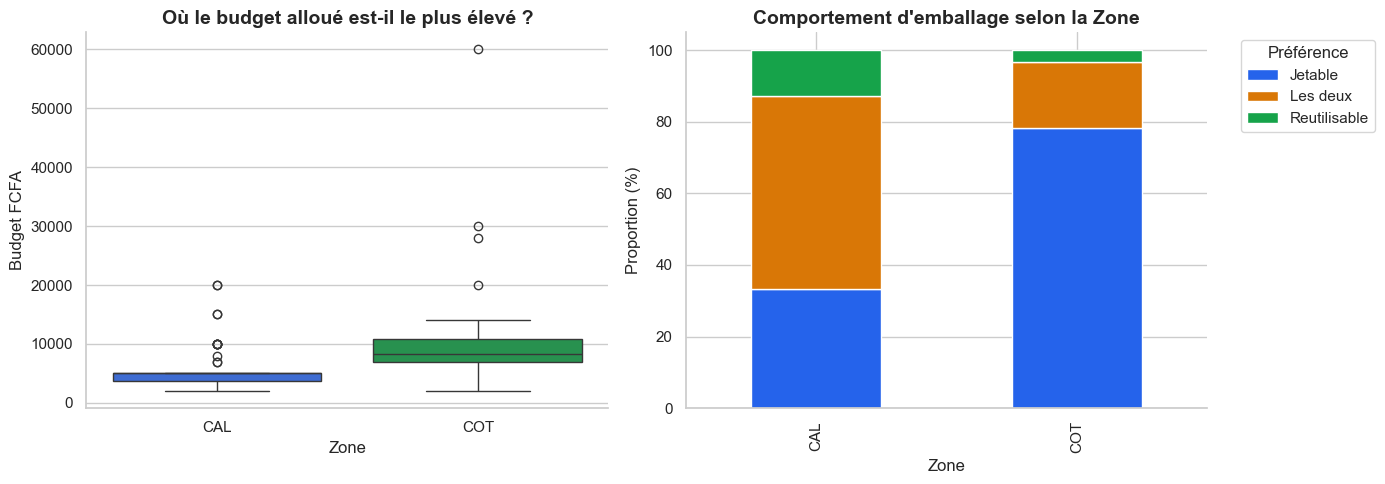

📌 Observation Spatiale :
Cotonou (COT) présente des budgets médians nettement supérieurs et une plus forte inclinaison pour le Jetable strict.
Calavi (CAL) est davantage ouvert aux solutions mixtes (Jetable + Réutilisable) avec un pouvoir d'achat plus modéré.


In [7]:

# --- CACHE / BUDGET PAR ZONE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="Zone", y="Budget_clean", data=df, palette=PALETTE_ZONES, ax=axes[0])
axes[0].set_title("Où le budget alloué est-il le plus élevé ?", fontweight="bold")
axes[0].set_ylabel("Budget FCFA")

# --- COMPORTEMENT JETABLE/RÉUTILISABLE PAR ZONE ---
pref_zone = pd.crosstab(df["Zone"], df[COL_PREF], normalize='index') * 100
colors_zone = [PALETTE_MAIN[0], PALETTE_MAIN[3], PALETTE_MAIN[1]]
pref_zone.plot(kind='bar', stacked=True, ax=axes[1], color=colors_zone, edgecolor='white')
axes[1].set_title("Comportement d'emballage selon la Zone", fontweight="bold")
axes[1].set_ylabel("Proportion (%)")
axes[1].legend(title="Préférence", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print("📌 Observation Spatiale :")
print("Cotonou (COT) présente des budgets médians nettement supérieurs et une plus forte inclinaison pour le Jetable strict.")
print("Calavi (CAL) est davantage ouvert aux solutions mixtes (Jetable + Réutilisable) avec un pouvoir d'achat plus modéré.")



## 7. Recommandations Stratégiques pour Cinnuex

À l'issue de l'analyse comportementale, financière et spatiale des besoins de vos clients, voici le plan d'action optimal :

### 📦 1. Développement Produit (Gamme Initiale)
*   **Format Star :** Lancez en priorité des plats de forme **Grande taille (1100 ML)** dotés de **2 compartiments**. (Le marché de la rue vend énormément de Mets Africains nécessitant la séparation pâte/sauce).
*   **Les Matériaux :** Le trio gagnant est **Carton durci, Bioplastique, Plastique résistant**.
*   **L'Obstacle n°1 (La chaleur & la sauce) :** Vous devez absolument garantir de façon hermétique la tolérance aux liquides et à la chaleur, avec un couvercle transparent résistant. C’est la garantie d’adoption n°1.

### 💰 2. Go-To-Market et Stratégie Tarifaire
*   Concevez un modèle dont la rentabilité permet d'écouler la centaine de plats autour de **5000 FCFA à 6500 FCFA**. Au-delà, l'acceptation baisse fortement.
*   Environ 36% du marché a clairement répondu **OUI** pour payer légèrement plus cher en échange d'une assurance Qualité/Zéro fuite. C'est votre "Marge Prime".

### 🚚 3. Distribution & Différenciation (Le Service Commercial)
*   **Modèle Hebdomadaire :** 55% de la base demande une livraison / approvisionnement hebdomadaire de proximité. Vous pouvez mettre en place des "Tournées Cinnuex" chaque lundi/mardi par zone géographique.
*   **Notifications :** Plusieurs répondants demandent un simple message/rappel sur WhatsApp avant le dépôt de la marchandise. Lier votre flotte de livraison à un algorithme WhatsApp automatisé fera très professionnel.

### 🌍 4. Stratégie de Segments (Cotonou vs Calavi)
*   Votre portefeuille à **Cotonou (COT)** cherche du **Jetable très agressif** avec des liquidités présentes (10.000 FCFA le budget moyen).
*   Votre portefeuille à **Calavi (CAL)** accepte le concept écologique/mixte des emballages, mais leur budget médian stagne autour de 5.000 FCFA. Il leur faut une formule plus modeste ou à plus grande valeur ajoutée durable.
